In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv(r"E:\archive (4)\Wine dataset.csv")

In [4]:
df

,class,Alcohol,Malic acid,Ash,Alcalinity of ash,Magnesium,Total phenols,Flavanoids,Nonflavanoid phenols,Proanthocyanins,Color intensity,Hue,OD280/OD315 of diluted wines,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,3,13.71,5.65,2.45,20.5,95,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740
174,3,13.40,3.91,2.48,23.0,102,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750
175,3,13.27,4.28,2.26,20.0,120,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835
176,3,13.17,2.59,2.37,20.0,120,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840


In [5]:
df = pd.read_csv(r"E:\archive (4)\Wine dataset.csv",header=None,usecols=[0, 1, 2])
df.columns = ['class', 'Alcohal', 'Malic acid']

In [6]:
df.head()

,class,Alcohal,Malic acid
0,class,Alcohol,Malic acid
1,1,14.23,1.71
2,1,13.2,1.78
3,1,13.16,2.36
4,1,14.37,1.95


In [34]:
import pandas as pd

# Remove the first row
df = df.iloc[1:].reset_index(drop=True)

# Convert the columns to numeric
df["Alcohal"] = pd.to_numeric(df["Alcohal"], errors="coerce")
df["Malic acid"] = pd.to_numeric(df["Malic acid"], errors="coerce")
df["class"] = pd.to_numeric(df["class"], errors="coerce")

print(df.dtypes)
print(df.head())

class         float64
Alcohal       float64
Malic acid    float64
dtype: object
   class  Alcohal  Malic acid
0    1.0    14.23        1.71
1    1.0    13.20        1.78
2    1.0    13.16        2.36
3    1.0    14.37        1.95
4    1.0    13.24        2.59


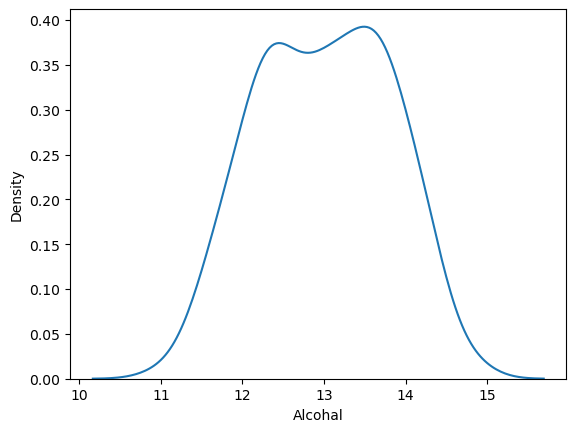

In [35]:
sns.kdeplot(x=df['Alcohal'])
plt.show()

<Axes: xlabel='Malic acid', ylabel='Density'>

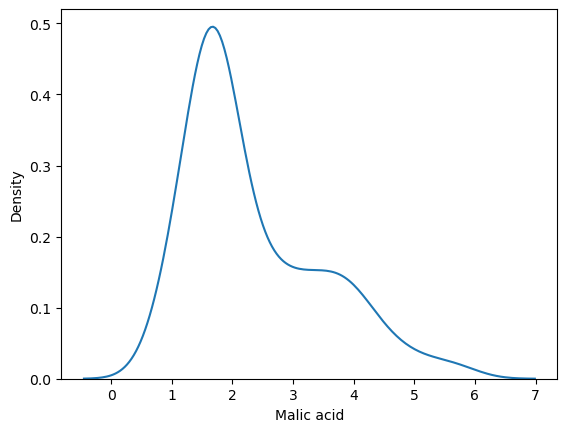

In [36]:
sns.kdeplot(x=df['Malic acid'])

In [37]:
x = df.drop('class', axis=1)  # Features
y = df['class']               # Target

In [49]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)
x_train.shape, x_test.shape

((142, 2), (36, 2))

In [46]:
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

# Convert all columns in x_train and x_test to numeric
x_train = x_train.apply(pd.to_numeric, errors='coerce')
x_test = x_test.apply(pd.to_numeric, errors='coerce')

# Remove rows with NaN values (created from strings like "Alcohol")
x_train = x_train.dropna()
x_test = x_test.dropna()

# Create the scaler
scaler = MinMaxScaler()

# Fit and transform
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [47]:
print(x_train_scaled[:5])
print(x_test_scaled[:5])

[[0.38172043 0.43584521]
 [0.72580645 0.12423625]
 [0.83064516 0.12016293]
 [0.54301075 0.17107943]
 [0.68010753 0.16700611]]
[[ 0.21774194  0.40733198]
 [ 0.69892473  0.18737271]
 [ 0.30645161  0.11405295]
 [ 0.10215054 -0.0305499 ]
 [ 0.16935484  0.20162933]]


In [48]:
x_train_scaled = pd.DataFrame(
    x_train_scaled,
    columns=x_train.columns,
    index=x_train.index
)

x_test_scaled = pd.DataFrame(
    x_test_scaled,
    columns=x_test.columns,
    index=x_test.index
)

print(x_train_scaled.head())

      Alcohal  Malic acid
158  0.381720    0.435845
31   0.725806    0.124236
12   0.830645    0.120163
51   0.543011    0.171079
41   0.680108    0.167006


In [51]:
x_train_scaled = pd.DataFrame(
    x_train_scaled,
    columns=x_train.columns,
    index=x_train.index
)

x_test_scaled = pd.DataFrame(
    x_test_scaled,
    columns=x_test.columns,
    index=x_test.index
)

print(x_train_scaled.head())

      Alcohal  Malic acid
158  0.381720    0.435845
137  0.327957    0.780041
98        NaN         NaN
159  0.889785    0.160896
38   0.543011    0.154786


In [56]:
x_train_scaled = pd.DataFrame(x_train_scaled, columns=x_train.columns)
x_test_scaled = pd.DataFrame(x_test_scaled, columns=x_test.columns) 

In [58]:
np.round(x_train_scaled.describe(), 1)

,Alcohal,Malic acid
count,124.0,124.0
mean,0.5,0.3
std,0.2,0.2
min,0.0,0.0
25%,0.4,0.2
50%,0.6,0.2
75%,0.7,0.5
max,1.0,1.0


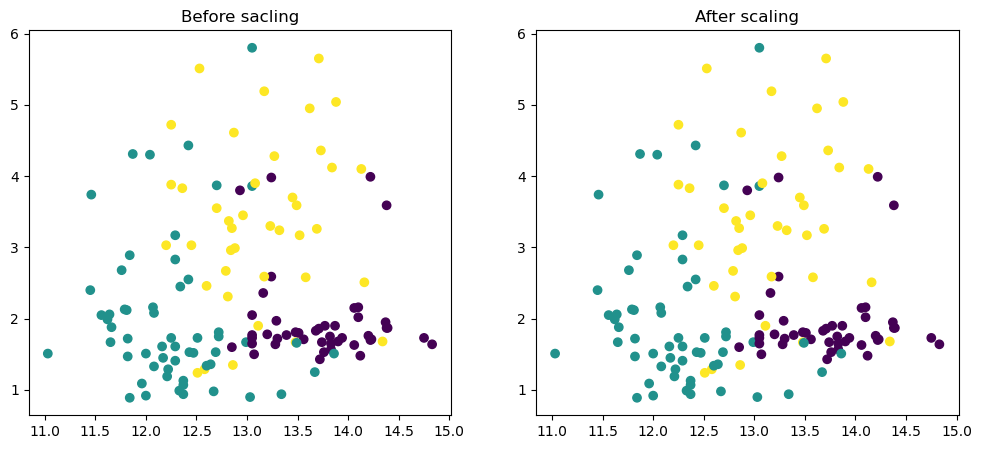

In [59]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12,5))

ax1.scatter(x_train['Alcohal'], x_train['Malic acid'],c=y_train)
ax1.set_title("Before sacling")
ax2.scatter(x_train['Alcohal'],x_train['Malic acid'], c=y_train)
ax2.set_title("After scaling")
plt.show()

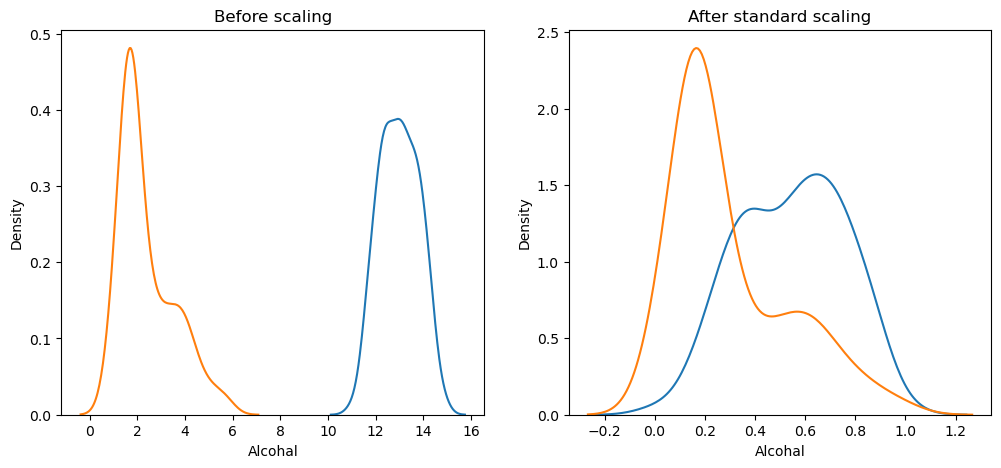

In [61]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12,5))

# before sacling
ax1.set_title("Before scaling")
sns.kdeplot(x_train['Alcohal'],ax=ax1)
sns.kdeplot(x_train['Malic acid'], ax=ax1)

# after scaling 
ax2.set_title("After standard scaling")
sns.kdeplot(x_train_scaled['Alcohal'], ax=ax2)
sns.kdeplot(x_train_scaled['Malic acid'], ax=ax2)
plt.show()

